# Treasury futures basis vs swaption — configurable backtest

Tests the **V2 leg** of the design's `V_spread = V1 + V2` decomposition:

    V1 = sigma_basis    - sigma_ustf_option    (delivery option vs listed option; needs a basket model)
    V2 = sigma_swaption - sigma_ustf_option    (OTC vs exchange; needs NO basis model, no repo)

V2 first, because it is nearly free and it can falsify the cross-product thesis before any
Monte Carlo over a deliverable basket exists.

**Trade.** When the spread is unusually low (`z < -entry_z`) the swaption is cheap relative to the
listed option: go long swaption vol / short futures-option vol, vega-matched, delta-hedged, both
legs priced as Bachelier options on a rate. And symmetrically for `z > +entry_z`.

---

## READ THIS BEFORE READING ANY P&L

Four properties of the underlying data bound what this backtest can claim. None of them is a
modelling choice; all were measured.

1. **The history is a single retrospective vintage.** `updated_at` on both source tables spans
   only **2026-03-12 to 2026-03-17**, for `as_of_date` running 2022-12-09 to 2026-03-13. The whole
   "history" was manufactured in one five-day window by running then-current code against whatever
   the vendors served then. It embeds subsequent revisions and a calibration chosen with full-sample
   knowledge. **Every number here is in-sample model output, not out-of-sample evidence.**
2. **The 1M/2M/3M slots are synthetic constant-maturity vols, not instruments.** `forward_price`
   and `fv01` are *identical across all three slots* on all 665 days — one front-contract forward
   serves every tenor. Listed options expire on fixed serial dates against specific contracts.
3. **The strike axis in the source table is corrupt on the futures leg** (a `/10_000` where `fv01`
   already carries per-bp units), so every stored "OTM" bucket sits ~1/100th of the requested
   distance from the forward. This notebook rebuilds that leg's smile from `smile_points`, which is
   delta-based and correct. The swaption leg's stored offsets are fine — differencing the two
   as-stored would have produced a large, stable, entirely artificial skew spread.
4. **There is no liquidity data at all** — no open interest, no bid/ask, no volume. Costs here are
   *assumed*, so the honest output is a **break-even cost multiple**, not a net P&L.

The `cost_mult` knob and the cost ladder in §7 exist because of (4).

## Order of operations

    load -> sanitize -> surfaces -> signal (CM slot) -> position (own remaining maturity)
         -> support gate -> gap guard -> roll guard -> P&L -> costs

## Three things the config cannot do

* It cannot re-enable `UL`. That product's forward yield moves 20bp across 3.3 years while US moves
  163bp, and a block of its rows has a dropped leading digit in the price. It is excluded as corrupt.
* It cannot price a position outside the quoted term structure while `require_on_support=True`.
  The 1M slot's apparent Sharpe of 1.94 lives entirely below the shortest quoted node and inverts
  to -0.19 on support.
* It cannot book P&L across a data gap or a contract roll. Both are re-anchored, never claimed.


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, pathlib, warnings
REPO = r"C:\Users\chris\clee\ARBS-bvv"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

from RVUtils.BasisVsVol import voldata as V, surfaces as S, strategy as ST, grid as G, analytics as A
from RVUtils.BasisVsVol import switch as SW

RESULTS = pathlib.Path(REPO) / "notebooks" / "backtests" / "basis_vs_vol" / "_results"
VD = V.load(products=list(ST.DEFAULT_UNIVERSE))
BOOK = S.SurfaceBook(VD)
print("universe:", VD.products())
print("dates   :", VD.dates().min().date(), "->", VD.dates().max().date(), f"({len(VD.dates())} days)")
print("vintage :", VD.ustf["updated_at"].min(), "->", VD.ustf["updated_at"].max())

universe: ['FV', 'TN', 'TU', 'TY', 'US']
dates   : 2022-12-09 -> 2026-03-13 (729 days)
vintage : 2026-03-12 13:25:32.835976+00:00 -> 2026-03-17 04:01:42.543476+00:00


## 1. CONFIG

Every knob of the strategy. Change here, re-run the notebook.

In [2]:
CONFIG = dict(
    # ---- instrument -----------------------------------------------------
    product        = "US",     # TU | FV | TY | TN | US        (UL excluded: corrupt)
    expiry_label   = "3M",     # 2M | 3M   (1M cannot stay on support)
    tail           = None,     # None -> PRODUCT_TAIL[product]; US->20Y
    offset_bps     = 0.0,      # signed strike offset from each leg's own forward
    # ---- signal ---------------------------------------------------------
    z_window       = 126,
    entry_z        = 2.0,
    exit_z         = 0.5,
    signal_on      = "level",  # level | change
    # ---- position -------------------------------------------------------
    max_hold_days  = 21,
    min_tte_days   = 10.0,
    exec_lag_days  = 1,        # signal at t, fill at t+1
    rehedge_days   = 1,        # 0 disables the delta hedge
    require_on_support = True,
    max_gap_days   = 5,
    roll_policy    = "exit",
    # ---- sizing / costs -------------------------------------------------
    target_vega_usd  = 100_000.0,
    ustf_cost_vol_bp = 0.5,    # per side, in bp of vol
    swpt_cost_vol_bp = 0.75,
    hedge_cost_bp    = 0.10,
    cost_mult        = 1.0,
)

CFG = ST.StrategyConfig(**CONFIG)
RES = ST.run_strategy(VD, CFG, BOOK)
print(CFG.key())
print(json.dumps(RES.diagnostics, indent=1, default=str))

US/3M/20Y/off+0/w126/e2/x0.5/h21/rh1/cm1
{
 "n_days": 652,
 "n_trades": 9,
 "days_in_pos": 78,
 "entries_blocked_by_roll": 0,
 "gap_exits": 2,
 "universe_note": "UL excluded: corrupt forward_yield"
}


## 2. Known-answer gate — the delivery option against a vendor sheet

Before trusting anything downstream, reproduce a number produced by a model this code does not
share. Source: J.P. Morgan *U.S. Futures and Options Package*, closes as of **2026-08-12**.

The two-bond Bachelier reduction (`switch.py`) says the CTD's net basis is an option on the
parallel shift, struck at the crossover. For **Ultra Bond Sep26** it should reproduce JPM's printed
delivery option value of `0-01`. For **Bond Sep26** it should *fail* — ZB has seven deliverables
above 1% delivery probability spanning 33 months, and a two-bond model can only see one switch.
That contrast is the empirical content of gate G7.

In [3]:
F_UB, F_ZB, TTE = 110.25, 109.03125, 49/365
SIG_UB = 0.1080 * F_UB / 0.17321      # JPM Opt.IVol 10.80% price vol -> bp yield vol
SIG_ZB = 0.0913 * F_ZB / 0.14768

ub_ctd = SW.Deliverable("T 4 Nov 52",     0.7383, SW.cf_adjusted_forward_price( 2.5, 0.7383, F_UB), 0.1215, prob=.858)
ub_alt = SW.Deliverable("T 2 1/4 Feb 52", 0.5154, SW.cf_adjusted_forward_price(10.0, 0.5154, F_UB), 0.0953, prob=.102)
zb_ctd = SW.Deliverable("T 5 May 45",     0.8892, SW.cf_adjusted_forward_price( 2.5, 0.8892, F_ZB), 0.1156, prob=.409)
zb_alt = SW.Deliverable("T 3 Nov 44",     0.6725, SW.cf_adjusted_forward_price( 5.5, 0.6725, F_ZB), 0.0952, prob=.128)

rows = []
for nm, c, a, sig, printed_dov, printed_shift in (
        ("Ultra Bond Sep26", ub_ctd, ub_alt, SIG_UB, 1.0,  28.3),
        ("Bond Sep26",       zb_ctd, zb_alt, SIG_ZB, 4.0,  10.9)):
    r = SW.delivery_option_two_bond(c, a, sig, TTE)
    rows.append(dict(contract=nm, sigma_bp=round(sig,1),
                     crossover_bp=round(r["s_star"],1), jpm_shift_bp=printed_shift,
                     two_bond_DOV_32=round(r["value"],2), jpm_DOV_32=printed_dov,
                     captured=f'{r["value"]/printed_dov:.0%}'))
KNOWN = pd.DataFrame(rows)
display(KNOWN)

assert abs(KNOWN.loc[0,"two_bond_DOV_32"] - 1.0) < 0.5, "UB tie-out broken"
assert KNOWN.loc[1,"two_bond_DOV_32"] < 0.6*4.0,        "ZB should be badly understated"
print("\nGATE PASSED: two-bond reproduces UB to within a tick and misses most of ZB, as designed.")

,contract,sigma_bp,crossover_bp,jpm_shift_bp,two_bond_DOV_32,jpm_DOV_32,captured
0,Ultra Bond Sep26,68.7,24.6,28.3,1.05,1.0,105%
1,Bond Sep26,67.4,14.5,10.9,1.40,4.0,35%



GATE PASSED: two-bond reproduces UB to within a tick and misses most of ZB, as designed.


## 3. Data-quality funnel

Everything dropped, and why. A row that vanishes silently is a row that flatters the result.

In [4]:
dq = V.data_quality_report(VD)
display(dq.style.format(precision=3))

raw = V.load(sanitize=False)
clean, dropped = V.sanitize_ustf(raw.ustf)
panel = RES.signal
gaps = pd.Series(panel.index).diff().dt.days
funnel = pd.DataFrame([
    ("rows in source table",              len(raw.ustf)),
    ("dropped: implausible price/yield",  -len(dropped)),
    ("dropped: UL excluded from universe", -int((clean["product"]=="UL").sum())),
    ("panel days for this config",        len(panel)),
    ("  of which flagged as a roll",      int(panel["is_roll"].sum())),
    ("  of which follow a >5d gap",       int((gaps>5).sum())),
    ("days with a usable z-score",        int(panel["z"].notna().sum())),
    ("trades",                            len(RES.trades)),
], columns=["stage","n"])
display(funnel)
print("\nnot-live rows (option outlives its referenced contract): "
      f'{int((~VD.ustf["is_live"]).sum())} / {len(VD.ustf)} '
      f'({100*(~VD.ustf["is_live"]).mean():.1f}%) -- the CM slots reference the FRONT contract')

mm = V.ustf_market_vs_model(VD.ustf)
print("\nSABR model-vs-market ATM bias on the futures leg (bp) -- the signal is 4-13bp:")
display(mm.groupby("product")["market_minus_model_bps"].agg(["count","mean","std"]).round(3))

,product,n_days,start,end,identity_max_err,median_atm_bps_3m,median_fv01,median_realized_bps,iv_over_rv,n_rolls,n_stale_days
0,FV,644,2022-12-09,2026-03-13,0.000,116.494,0.042,101.464,1.072,39,0
1,TN,462,2023-05-09,2026-03-13,0.000,98.947,0.089,85.513,1.129,30,0
2,TU,613,2022-12-09,2026-03-06,0.000,117.162,0.018,115.189,1.031,39,0
3,TY,679,2022-12-09,2026-03-13,0.000,112.667,0.065,100.723,1.069,39,0
4,US,665,2022-12-09,2026-03-13,0.000,104.993,0.136,109.609,0.973,39,0


,stage,n
0,rows in source table,11195
1,dropped: implausible price/yield,-642
2,dropped: UL excluded from universe,-1365
3,panel days for this config,652
4,of which flagged as a roll,12
5,of which follow a >5d gap,14
6,days with a usable z-score,593
7,trades,9



not-live rows (option outlives its referenced contract): 4851 / 9188 (52.8%) -- the CM slots reference the FRONT contract



SABR model-vs-market ATM bias on the futures leg (bp) -- the signal is 4-13bp:


,count,mean,std
product,,,
FV,1931,0.832,0.543
TN,1386,0.389,1.019
TU,1839,0.958,0.848
TY,2037,1.034,0.427
US,1995,0.812,0.323


## 4. Performance of the configured cell

P&L is reported in **vol bp** = dollars / `target_vega_usd`, so it is scale-free: `1.0` means the
package made one basis point of vol on its vega.

,value
n_days,652.000
days_in_pos,78.000
total_volbp,18.410
ann_volbp,7.115
ann_vol,17.383
sharpe,0.409
t_naive,0.659
t_nw,0.503
nw_lags,12.000
max_dd_volbp,-20.773


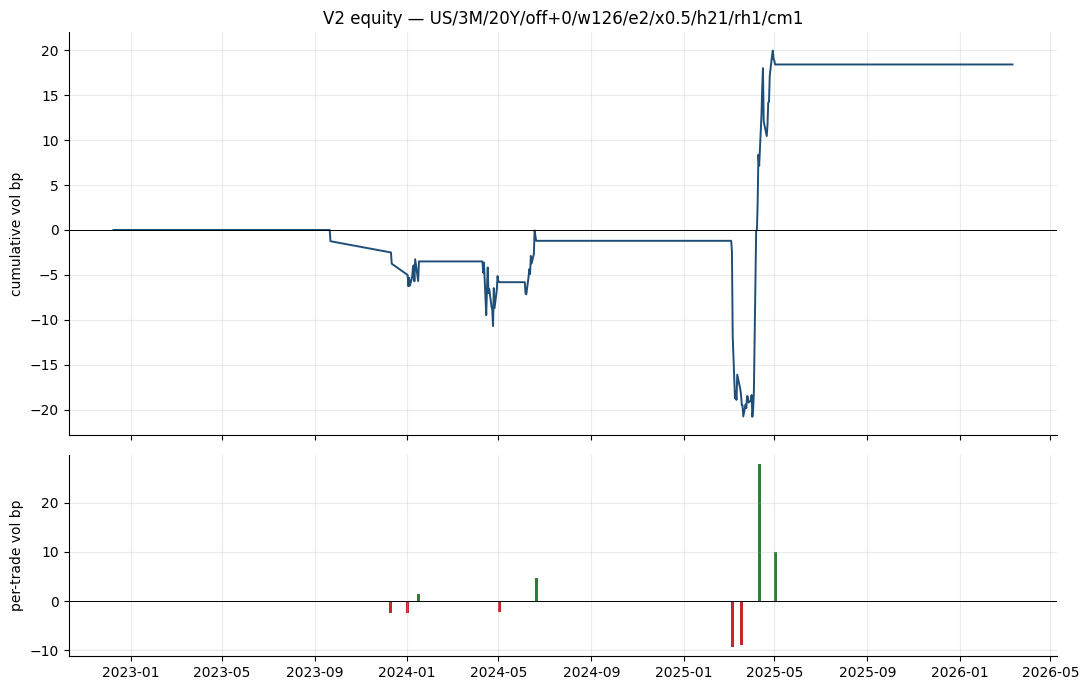

,count,mean,sum
reason,,,
gap,2,-2.500,-5.000
max_hold,3,11.866,35.597
roll,2,-2.153,-4.305
z_exit,2,-3.941,-7.882


In [5]:
summ = A.summarize(RES.daily, RES.trades)
display(pd.Series(summ).to_frame("value").style.format(precision=3))

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={"height_ratios":[2,1]})
ax[0].plot(RES.daily.index, RES.daily["equity_volbp"], lw=1.4, color="#1f4e79")
ax[0].axhline(0, color="k", lw=.7)
ax[0].set_ylabel("cumulative vol bp"); ax[0].set_title(f"V2 equity — {CFG.key()}")
if len(RES.trades):
    t = RES.trades
    ax[1].bar(pd.to_datetime(t["exit_date"]), t["pnl_volbp"],
              width=pd.Timedelta(days=4),
              color=np.where(t["pnl_volbp"]>0, "#2e7d32", "#c62828"))
ax[1].axhline(0, color="k", lw=.7); ax[1].set_ylabel("per-trade vol bp")
plt.tight_layout(); plt.show()

if len(RES.trades):
    display(RES.trades.groupby("reason")["pnl_volbp"].agg(["count","mean","sum"]).round(3))

## 5. The support gate

The vol term structure is quoted at three nodes (30/60/90 days). Below the shortest one the
surface holds vol flat, because there is nothing to interpolate — a position priced there is priced
outside the data.

This is not a technicality. It is the difference between a headline result and no result.

In [6]:
from dataclasses import replace as _replace
rows = []
for lbl in ("1M","2M","3M"):
    for on in (False, True):
        c = _replace(CFG, expiry_label=lbl, require_on_support=on)
        d, t, _ = G.pool_products(VD, c, book=BOOK)
        if d.empty: continue
        s = A.summarize(d, t); s.update(expiry=lbl, on_support=on)
        rows.append(s)
SUP = pd.DataFrame(rows)
display(SUP[["expiry","on_support","n_trades","mean_volbp","hit_rate","sharpe","t_nw",
             "top3_share","cost_over_gross"]].round(3))
print("\nThe 1M row is the whole lesson: an edge that only exists where the surface is extrapolated.")

,expiry,on_support,n_trades,mean_volbp,hit_rate,sharpe,t_nw,top3_share,cost_over_gross
0,1M,False,45,6.352,0.756,1.979,3.503,0.253,0.259
1,1M,True,24,-0.591,0.333,-0.185,-0.325,-2.992,1.316
2,2M,False,45,0.319,0.556,0.091,0.261,2.199,0.882
3,2M,True,45,0.319,0.556,0.091,0.261,2.199,0.882
4,3M,False,38,0.030,0.447,0.014,0.024,44.859,0.988
5,3M,True,38,0.030,0.447,0.014,0.024,44.859,0.988



The 1M row is the whole lesson: an edge that only exists where the surface is extrapolated.


## 6. Grid search

Pooled across the five-product universe (equal vega each). Pooling is the only route to usable
power: one product yields ~20 trades over the sample.

In [7]:
AXES = dict(entry_z=[1.0,1.5,2.0,2.5], max_hold_days=[10,21,42],
            z_window=[63,126,252], offset_bps=[-25.,0.,25.])
cfgs = G.expand_grid(_replace(CFG, require_on_support=True), **AXES)
print(f"{len(cfgs)} cells x {len(ST.DEFAULT_UNIVERSE)} products")
GRID, _ = G.run_pooled_grid(VD, cfgs, book=BOOK)
display(GRID.sort_values("sharpe", ascending=False)
        [["entry_z","max_hold_days","z_window","offset_bps","n_trades","mean_volbp",
          "hit_rate","sharpe","t_nw","top3_share","cost_over_gross"]].head(12).round(3))

108 cells x 5 products


,entry_z,max_hold_days,z_window,offset_bps,n_trades,mean_volbp,hit_rate,sharpe,t_nw,top3_share,cost_over_gross
102,2.5,42,126,-25.0,24,1.395,0.458,0.720,1.296,1.250,0.548
93,2.5,21,126,-25.0,24,1.349,0.458,0.707,1.280,1.335,0.554
69,2.0,21,252,-25.0,31,1.057,0.581,0.539,1.010,1.214,0.616
87,2.5,10,252,-25.0,20,2.013,0.600,0.504,0.811,1.416,0.562
60,2.0,10,252,-25.0,36,0.871,0.556,0.475,0.910,1.695,0.658
78,2.0,42,252,-25.0,31,1.476,0.581,0.376,1.096,1.032,0.556
84,2.5,10,126,-25.0,25,0.304,0.440,0.347,0.645,4.291,0.729
105,2.5,42,252,-25.0,17,1.348,0.647,0.343,0.611,1.554,0.660
51,1.5,42,252,-25.0,68,0.566,0.515,0.331,0.689,1.023,0.807
75,2.0,42,126,-25.0,42,0.762,0.500,0.327,0.679,1.173,0.777


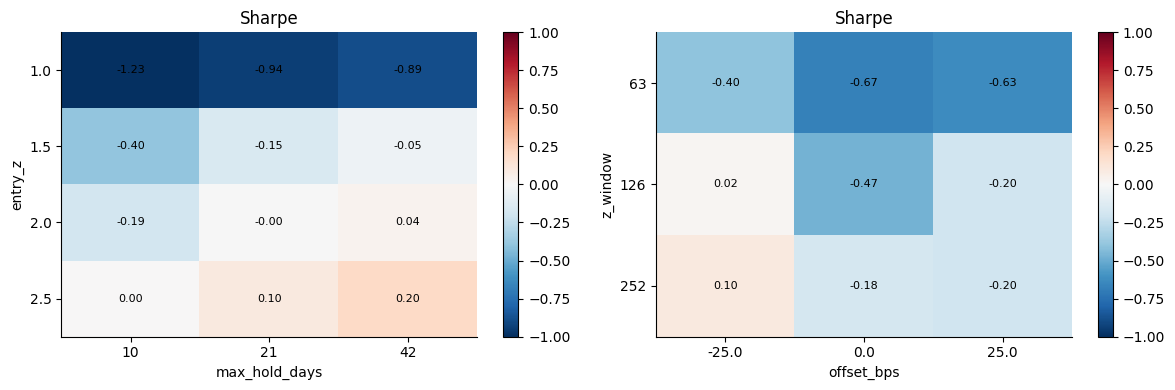

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (r, c, ttl) in zip(axes, [("entry_z","max_hold_days","Sharpe"),
                                  ("z_window","offset_bps","Sharpe")]):
    piv = GRID.pivot_table(index=r, columns=c, values="sharpe", aggfunc="mean")
    im = ax.imshow(piv.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(piv.columns)), piv.columns); ax.set_yticks(range(len(piv.index)), piv.index)
    ax.set_xlabel(c); ax.set_ylabel(r); ax.set_title(ttl); ax.grid(False)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 7. Cost ladder — the only honest headline

There is no liquidity data in the source tables, so the cost assumption is exactly that. Report the
**break-even multiple**: how much worse than assumed can execution be before the edge is gone.

,cost_mult,n_trades,mean_volbp,hit_rate,sharpe,t_nw
0,0.0,24,3.821,0.792,1.565,2.598
1,0.5,24,2.608,0.583,1.154,2.000
2,1.0,24,1.395,0.458,0.720,1.296
3,1.5,24,0.181,0.333,0.280,0.518
4,2.0,24,-1.032,0.333,-0.148,-0.278
5,3.0,24,-3.458,0.250,-0.916,-1.705



break-even cost multiple: 1.50x the assumed bid/offer


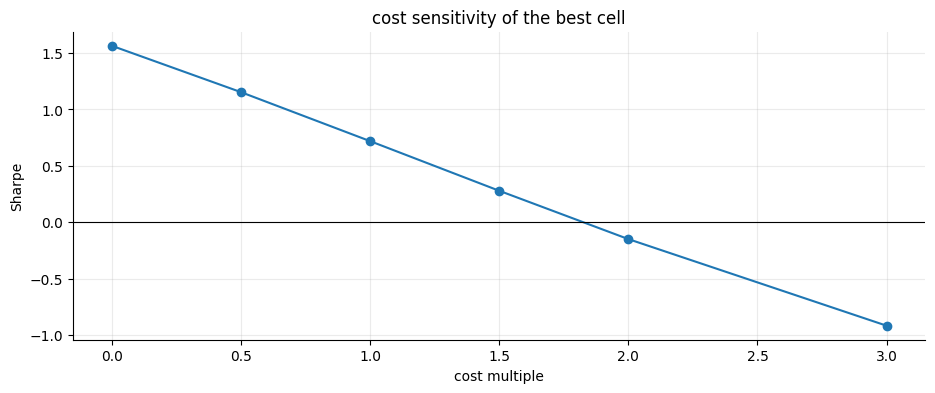

In [9]:
BEST = GRID.sort_values("sharpe", ascending=False).iloc[0]
best_cfg = next(c for c in cfgs if c.key() == BEST["key"])
LADDER = G.cost_ladder(VD, best_cfg, book=BOOK, mults=(0.0,0.5,1.0,1.5,2.0,3.0))
display(LADDER[["cost_mult","n_trades","mean_volbp","hit_rate","sharpe","t_nw"]].round(3))

alive = LADDER[LADDER["sharpe"] > 0]["cost_mult"]
print(f"\nbreak-even cost multiple: "
      f"{alive.max() if len(alive) else 0:.2f}x the assumed bid/offer")
plt.plot(LADDER["cost_mult"], LADDER["sharpe"], "o-"); plt.axhline(0, color="k", lw=.8)
plt.xlabel("cost multiple"); plt.ylabel("Sharpe"); plt.title("cost sensitivity of the best cell")
plt.show()

## 8. Placebos

A result that survives a deliberately wrong pairing, or that a coin flip reproduces, is not a
measurement of a cross-product wedge.

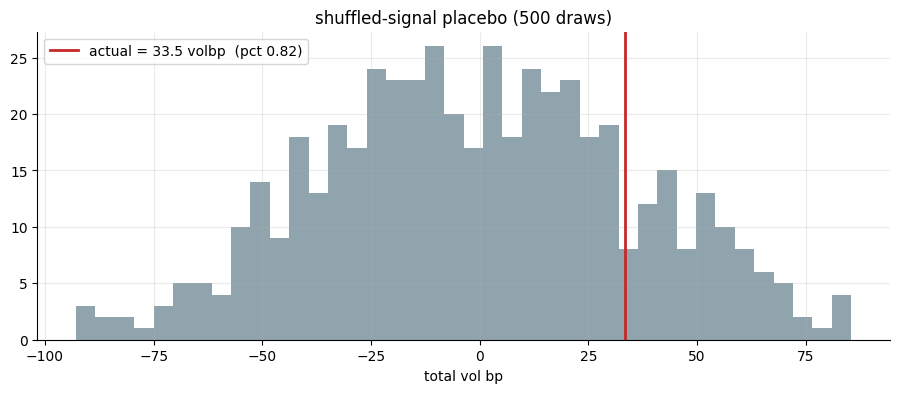

,product,tail,pairing,n_trades,mean_volbp,sharpe,t_nw
0,US,20Y,matched,6,3.754,0.718,1.017
1,US,2Y,mismatched,2,-0.385,-0.057,-0.182
2,TY,7Y,matched,8,-0.147,0.410,0.832
3,TY,2Y,mismatched,4,-2.171,-0.231,-0.666


A mismatched pair that performs like the matched one means the signal is not about the pair.


In [10]:
PLAC = G.shuffled_signal_placebo(VD, best_cfg, book=BOOK, n_draws=500)
act = PLAC.attrs["actual_total"]
pct = float((PLAC["total_volbp"] < act).mean())
plt.hist(PLAC["total_volbp"], bins=40, color="#90a4ae")
plt.axvline(act, color="#c62828", lw=2, label=f"actual = {act:.1f} volbp  (pct {pct:.2f})")
plt.legend(); plt.title("shuffled-signal placebo (500 draws)"); plt.xlabel("total vol bp"); plt.show()

MIS = G.mismatched_pair_placebo(VD, best_cfg, book=BOOK, wrong_tail="2Y", products=("US","TY"))
display(MIS[["product","tail","pairing","n_trades","mean_volbp","sharpe","t_nw"]].round(3))
print("A mismatched pair that performs like the matched one means the signal is not about the pair.")

## 9. What the search cost

The grid is a multiple-testing machine. The deflated Sharpe asks whether the best cell beats what
this many random cells would have produced anyway.

Note the effective breadth is far below the cell count: the five products are near-collinear
duration-vol bets, and at a 2–3 month horizon the daily observations overlap almost completely.

In [11]:
dfl = G.deflate_grid(GRID, G.pool_products(VD, best_cfg, book=BOOK)[0]["pnl_volbp"])
display(pd.Series(dfl).to_frame("value").style.format(precision=4))

best_daily, best_trades, _ = G.pool_products(VD, best_cfg, book=BOOK)
lo, hi = A.block_bootstrap_ci(best_daily["pnl_volbp"], block=21, n_boot=2000)
print(f"block-bootstrap 95% CI on Sharpe: [{lo:.2f}, {hi:.2f}]")
print(f"n_trials={dfl['n_trials']}   E[max Sharpe | null]={dfl['expected_max_sharpe']:.3f}"
      f"   best={dfl['best_sharpe']:.3f}")
ALIVE = (dfl["dsr"] > 0.95) and (BEST["top3_share"] < 0.6) and (pct > 0.95)
print(f"\nALIVE = {ALIVE}   (DSR>0.95 AND top3<0.6 AND placebo pct>0.95)")

,value
n_trials,108.0000
sr_variance,0.3044
expected_max_sharpe,1.4112
dsr,0.0961
best_sharpe,0.7201


block-bootstrap 95% CI on Sharpe: [-0.42, 1.60]
n_trials=108   E[max Sharpe | null]=1.411   best=0.720

ALIVE = False   (DSR>0.95 AND top3<0.6 AND placebo pct>0.95)


## 10. Regime split

2022-12 to 2026-03 spans a hiking cycle, a plateau and a cutting cycle. A strategy alive in one
year and dead in three is not alive.

,period,n_days,total_volbp,sharpe
0,2022,14,0.000,NaN
1,2023,171,0.000,NaN
2,2024,246,12.156,0.435
3,2025,237,21.316,0.936
4,2026,48,15.565,2.112


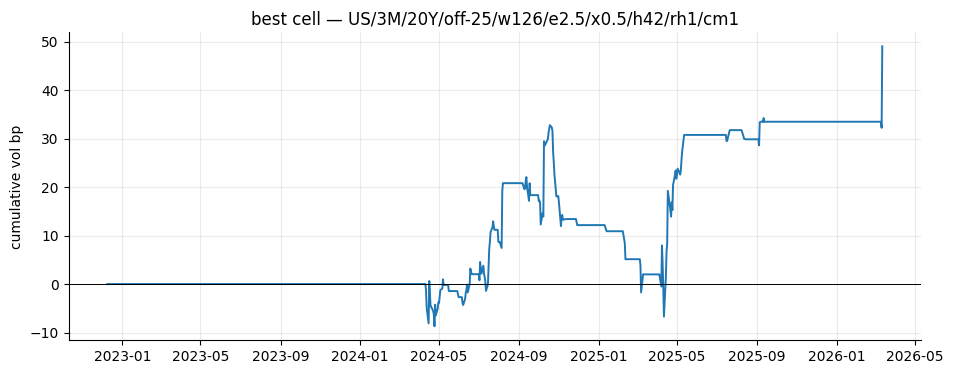

In [12]:
display(A.regime_split(best_daily).round(3))
plt.plot(best_daily.index, best_daily["pnl_volbp"].cumsum(), lw=1.4)
plt.axhline(0, color="k", lw=.7); plt.ylabel("cumulative vol bp")
plt.title(f"best cell — {best_cfg.key()}"); plt.show()

## 11. QueryDrivenBacktest cross-check

The same trade schedule run through the repo's backtest engine — its MDP, query, adapter, position
handler and trigger machinery — against the standalone vectorised engine. They share only the
Bachelier primitives and the surfaces.

Costs are zeroed for the comparison: the framework has no entry-side fee hook, so the two cost
conventions differ by construction. Pricing is what is being compared, and it must agree exactly.

This check earned its keep: it found that the reference engine was booking the contract-roll price
gap as P&L.

QueryDrivenBacktest : 4,021,248.97
reference engine    : 4,021,248.97
difference          : 0.000000
closed positions    : 9 vs 9 trades


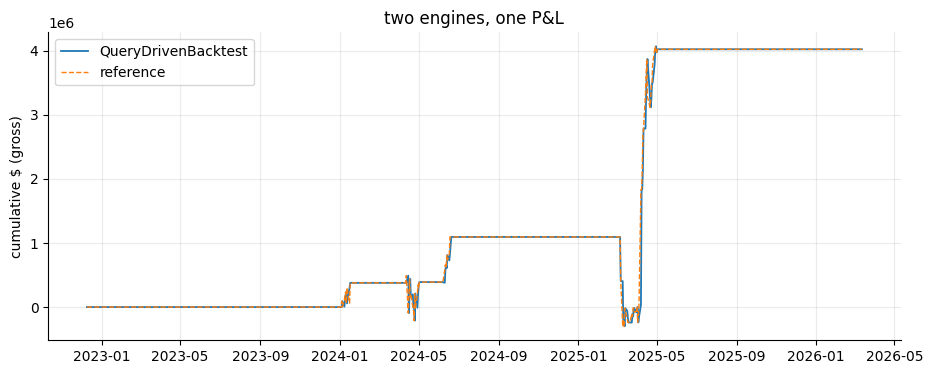

In [13]:
from BT.signals.basis_vs_vol import run_bvv_qdb_backtest, qdb_equity_series
c0 = _replace(CFG, ustf_cost_vol_bp=0.0, swpt_cost_vol_bp=0.0, hedge_cost_bp=0.0)
bt, ref = run_bvv_qdb_backtest(VD, c0, BOOK)
eq = qdb_equity_series(bt)
q, r = float(eq.iloc[-1]), float(ref.daily["gross_pnl"].sum())
print(f"QueryDrivenBacktest : {q:,.2f}")
print(f"reference engine    : {r:,.2f}")
print(f"difference          : {q-r:,.6f}")
print(f"closed positions    : {len(bt.portfolio.closed_positions_log)} vs {len(ref.trades)} trades")
assert abs(q-r) < 1e-2, "engines disagree"

plt.plot(eq.index, eq.values, lw=1.3, label="QueryDrivenBacktest")
plt.plot(ref.daily.index, ref.daily["gross_pnl"].cumsum(), lw=1.0, ls="--", label="reference")
plt.legend(); plt.ylabel("cumulative $ (gross)"); plt.title("two engines, one P&L"); plt.show()

## 12. Reading guide

**What a positive result here would and would not mean.** Given the four data properties in the
header, a positive V2 result is evidence about a *synthetic constant-maturity vol series inside a
single retrospective vintage*. It is not evidence that a tradeable position would have made money.
To convert one into the other you would need: listed expiries instead of CM slots, a point-in-time
vintage, and a quote/OI source for costs.

**The order to read the sections in.**

| § | question it answers |
|---|---|
| 2 | does the delivery-option maths reproduce a number from outside this code? |
| 3 | what was thrown away, and does the discarded set look random? |
| 5 | is the result an artifact of pricing outside the data? |
| 7 | how much of the edge is a cost assumption? |
| 8 | would a coin flip, or a deliberately wrong pair, have done as well? |
| 9 | what did the search cost, and does the best cell clear it? |
| 11 | do two independent engines agree on the P&L? |

**Kill conditions, pre-registered.** A cell is alive only if DSR > 0.95 against the full trial
count, it survives 2x costs, it beats the shuffled-signal placebo at the 95th percentile, and its
top three trades are under 60% of total P&L. Any one of those failing is a dead cell — including
when the Sharpe looks good.